In [1]:
import alphapepttools as apt
import matplotlib as mpl
import matplotlib.pyplot as plt
import mudata as md
import muon
import numpy as np
import pandas as pd
import seaborn as sns

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
# Mirror the central alphapepttools plot settings (defaults.PlotSettings) onto matplotlib's
# global rcParams so notebook figures match the library defaults.
from alphapepttools.pl import defaults

_plot_config = defaults.plot_settings.to_dict()
plt.rcParams.update(
    {
        "font.size": _plot_config["font_sizes"]["medium"],
        "axes.titlesize": _plot_config["axes"]["title_size"],
        "axes.labelsize": _plot_config["axes"]["label_size"],
        "xtick.labelsize": _plot_config["axes"]["tick_size"],
        "ytick.labelsize": _plot_config["axes"]["tick_size"],
        "legend.fontsize": _plot_config["legend"]["font_size"],
        "legend.title_fontsize": _plot_config["legend"]["title_size"],
        "lines.linewidth": _plot_config["linewidths"]["medium"],
        "lines.markersize": _plot_config["marker_sizes"]["medium"],
        "figure.dpi": _plot_config["resolution"]["dpi"],
        "savefig.dpi": _plot_config["resolution"]["dpi"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

In [3]:
mdata = md.read_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/sit

In [4]:
total_explained_variance = pd.DataFrame(mdata.uns["mofa"]["variance"]).sum(axis=1)

## Factor activity

In [5]:
list(sns.color_palette("Accent").as_hex())

palette = [
    "#6CC196",
    "#beaed4", 
    "#fdc086", 
    "#555555", 
    "#386cb0"]

In [6]:
DIM_X, DIM_Y = 0, 2

VAR_X = total_explained_variance.loc[DIM_X]
VAR_Y = total_explained_variance.loc[DIM_Y]

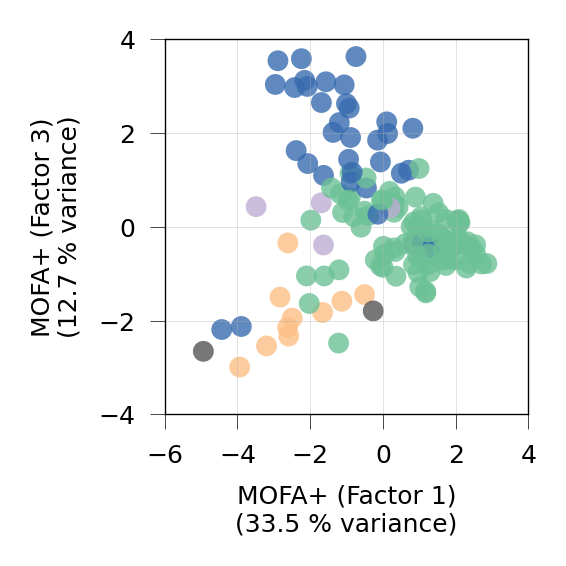

In [7]:
# Keep only the spine/axis styling that defaults.PlotSettings does not govern;
# font sizes and weights now follow the global rcParams derived from defaults.
plot_params = {
    "axes.linewidth": 1.0,
}

with mpl.rc_context(plot_params):
    fig, ax = apt.pl.create_figure(1, 1, figsize=("0.5", "0.5"))
    muon.pl.embedding(
        mdata,
        basis="X_mofa",
        dimensions=(DIM_X, DIM_Y),
        ax=ax[0],
        show=False,
        alpha=0.8,
        size=100,
        color="who2015_histology",
        title="",
        palette=palette,
        zorder=1
    )
    xmin, xmax = ax[0].get_xlim()
    ymin, ymax = ax[0].get_ylim()

    ax[0].set_xticks(np.arange(np.floor(xmin), xmax+1, 2))
    ax[0].set_yticks(np.arange(np.floor(ymin), ymax+1, 2))
    ax[0].grid(visible=True, which="major", alpha=0.5, zorder=-np.inf)

    legend = ax[0].legend()
    handles, labels = ax[0].get_legend_handles_labels()
    legend.remove()

    ax[0].set_xlabel(f"MOFA+ (Factor {DIM_X+1})\n({VAR_X:.1f} % variance)")
    ax[0].set_ylabel(f"MOFA+ (Factor {DIM_Y+1})\n({VAR_Y:.1f} % variance)")

fig.savefig("../data/plots/mofa-embedding.png", bbox_inches="tight", transparent=True)
plt.show()

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_13073/4205982035.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


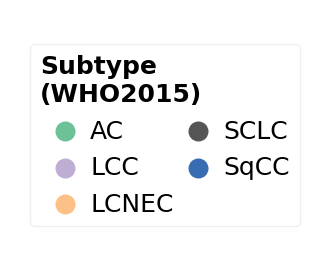

In [8]:
for handle in handles:
    handle.set_sizes([20])
    
fontsize=6


fig, axm = apt.pl.create_figure(1, 1, figsize=("0.25", "0.25"))
ax = axm.next()

ax.legend(
    handles,
    labels,
    loc="center",
    title="Subtype\n(WHO2015)",
    title_fontproperties={"weight": "bold", "size": fontsize},
    alignment="left",
    fontsize=fontsize,
    facecolor="#ffffff",
    framealpha=0.3,
    # edgecolor=",
    ncols=2,
    columnspacing=0.0,
    frameon=True,
    handletextpad=0.,
)
ax.set_axis_off()
plt.tight_layout()
fig.savefig("../data/plots/mofa-embedding.legend.png", bbox_inches="tight", dpi=600, transparent=True)
plt.show()